# Assignment 3

In [1]:
#!pip install voila

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 14.1 MB/s eta 0:00:00a 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [10]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd





df = pd.read_csv('nyc_311_sample_20k.csv')



# Rename API columns so the rest of your notebook still works

#df = df.sample(n=20000, random_state=42)

columns_to_keep = [
    "Created Date",
    "Closed Date",
    "Problem (formerly Complaint Type)",
    "Location Type",
    "Status"
]
df = df[columns_to_keep]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Created Date                       20000 non-null  object
 1   Closed Date                        18844 non-null  object
 2   Problem (formerly Complaint Type)  20000 non-null  object
 3   Location Type                      17654 non-null  object
 4   Status                             20000 non-null  object
dtypes: object(5)
memory usage: 781.4+ KB


# Dataset and Cleaning
## For this assignment, the dataset that I decided to use is a subet of NYC 311 service requests whichi only incudes requests from Manhattan from October 2025 to December 2025. The clean_311_data functions cleans the data by converting the date fields to datetime format, handling missing values, and adding attributes such as day of the week and hour for analysis. 

In [11]:

def clean_311_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df = df.rename(columns={
        "Problem (formerly Complaint Type)": "Complaint Type"
    })

    df["Created Date"] = pd.to_datetime(df["Created Date"], errors="coerce")
    df["Closed Date"] = pd.to_datetime(df["Closed Date"], errors="coerce")


    df["Complaint Type"] = df["Complaint Type"].astype("string").str.strip()
    df["Status"] = df["Status"].astype("string").str.strip().str.title()

    df = df.dropna(subset=["Created Date", "Complaint Type", "Status"])

    df["date"] = df["Created Date"].dt.date
    df["year_month"] = df["Created Date"].dt.to_period("M").astype(str)
    df["month"] = df["Created Date"].dt.month_name()
    df["day_of_week"] = df["Created Date"].dt.day_name()
    df["hour"] = df["Created Date"].dt.hour

    return df
cleaned_df = clean_311_data(df)
cleaned_df.head(5)

/tmp/ipykernel_605/1793468817.py:9: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



,Created Date,Closed Date,Complaint Type,Location Type,Status,date,year_month,month,day_of_week,hour
0,2025-10-22 05:07:01,2025-10-22 15:59:51,Drug Activity,Hallway,Closed,2025-10-22,2025-10,October,Wednesday,5
1,2025-10-15 08:26:06,2025-10-15 08:35:09,Vendor Enforcement,Street,Closed,2025-10-15,2025-10,October,Wednesday,8
2,2025-12-03 11:19:35,2026-01-09 14:19:49,WATER LEAK,RESIDENTIAL BUILDING,Closed,2025-12-03,2025-12,December,Wednesday,11
3,2025-10-30 18:40:38,2025-10-31 19:25:46,HEAT/HOT WATER,RESIDENTIAL BUILDING,Closed,2025-10-30,2025-10,October,Thursday,18
4,2025-11-05 12:58:09,NaT,UNSANITARY CONDITION,RESIDENTIAL BUILDING,Open,2025-11-05,2025-11,November,Wednesday,12


# Visualization Technique - Line Plot- Daily Count
### A line plot is used to visualize the number of complaints over time. This type of plot is well-suited for time series data because it makes it easy to identify trends, spikes, and changes across a continuous time axis.
### In this dashboard, the line plot serves as the overall “trend view,” showing how complaint volume changes throughout the selected date range

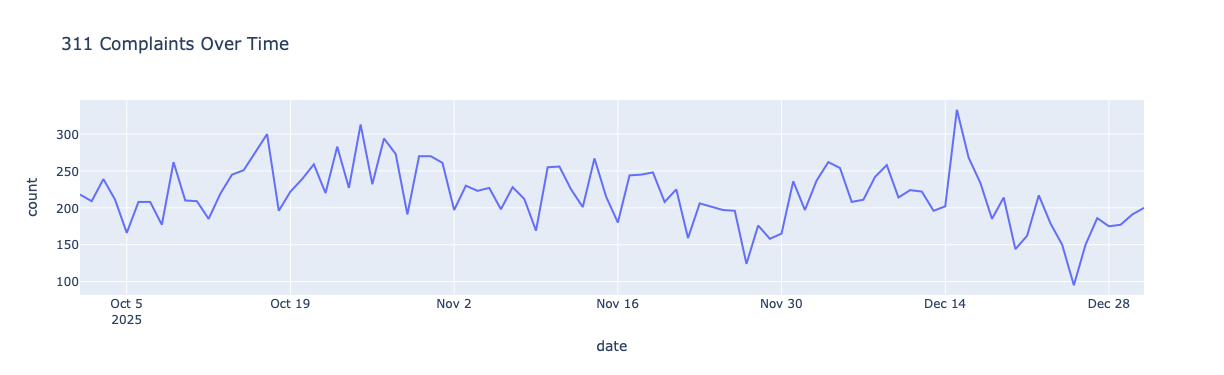

In [12]:

daily_counts = cleaned_df.groupby("date").size().reset_index(name="count")

line_plot = px.line(
    daily_counts,
    x="date",
    y="count",
    title="311 Complaints Over Time"
)
line_plot.show()



# Visualization Technique - Bar Chart - Complaint Type
### A line chart is used to visualize the number of complaints over time. This type of chart is well-suited for time series data because it makes it easy to identify trends, spikes, and changes across a continuous time axis.
### In this dashboard, the line chart serves as the overall “trend view,” showing how complaint volume changes throughout the selected date range

In [3]:
top_types = cleaned_df["Complaint Type"].value_counts().nlargest(10).index
filtered_df = cleaned_df[cleaned_df["Complaint Type"].isin(top_types)]
complaint_type_counts = filtered_df.groupby('Complaint Type').size().reset_index(name="count")
bar_chart = px.bar(complaint_type_counts, x='Complaint Type',y='count', title = 'Top 10 Complaints Count')
bar_chart.show()

# Visualization Technique - Bar Chart - Location Type
### A bar chart is used to show the distribution of complaints across different location types, such as residential buildings, streets, or other environments.
### This visualization provides context about where complaints are occurring, complementing the complaint type chart. It also shows whether certain issues occur more in certain types of locations.

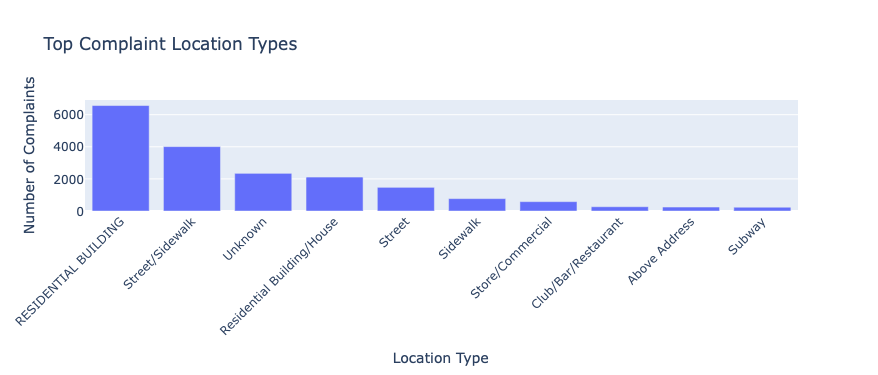

In [8]:
location_counts = (
    cleaned_df["Location Type"]
    .fillna("Unknown")
    .value_counts()
    .nlargest(10)
    .reset_index()
)

location_counts.columns = ["Location Type", "count"]

fig = px.bar(
    location_counts,
    x="Location Type",
    y="count",
    title="Top Complaint Location Types"
)

fig.update_layout(
    xaxis_title="Location Type",
    yaxis_title="Number of Complaints"
)

fig.update_xaxes(tickangle=-45)

fig.show()

# Visualization Technique - Bar Chart - Day of the Week
### A bar chart is also used to analyze complaints by day of the week. This helps identify recurring patterns in how complaints are distributed across weekdays and weekends.
### Unlike the overall time trend, this chart focuses on cyclical behavior. For example, it can reveal whether certain types of complaints are more common on weekends or during the workweek.

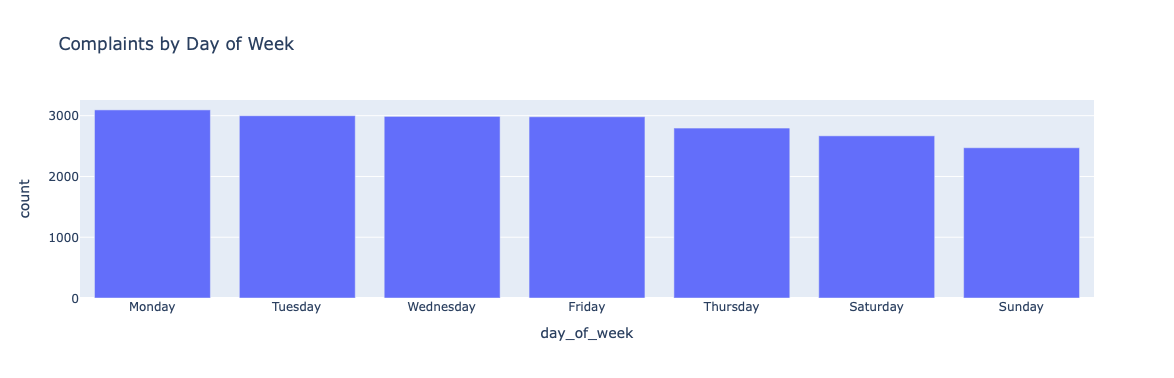

In [4]:
day_counts = (
    cleaned_df["day_of_week"]
    .value_counts()
    .reset_index()
)

day_counts.columns = ["day_of_week", "count"]

fig = px.bar(
    day_counts,
    x="day_of_week",
    y="count",
    title="Complaints by Day of Week"
)

fig.show()

# Visualization Library - Plotly and ipywidgets
### I chose to build the dashboard using Plotly and ipywidgets because they both easily integrate within a Jupyter Notebook environment.
### Plotly alllows for features such as zooming, panning and hovering without additional configuration.Plotly also follows a declaratie approach where visualizations are defined by mapping between data and visual properties
### ipywidgets adds interactivity to the dashboard throguh dropdown menus and sliders. For this dashboard, ipywidgets allows users to control filters such as complaint type and date range. When a widget value changes, the dashboard updates automatically and regenerates the visualizations based on the filters.

In [5]:
def create_dashboard(data):
    """
    Create a 2x2 dashboard of 311 complaint visualizations.

    Parameters
    ----------
    data : pandas.DataFrame
        Filtered dataframe used for plotting.

    Returns
    -------
    plotly.graph_objects.Figure
        Dashboard figure containing 4 charts.
    """

    # Chart 1: complaints over time
    daily_counts = data.groupby("date").size().reset_index(name="count")

    # Chart 2: complaint type counts
    complaint_counts = (
        data["Complaint Type"]
        .value_counts()
        .nlargest(10)
        .reset_index()
    )
    complaint_counts.columns = ["Complaint Type", "count"]

    # Chart 3: day of week counts
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    day_counts = data.groupby("day_of_week").size().reset_index(name="count")
    day_counts["day_of_week"] = pd.Categorical(
        day_counts["day_of_week"],
        categories=day_order,
        ordered=True
    )
    day_counts = day_counts.sort_values("day_of_week")

    # Chart 4: location type counts
    location_counts = (
        data["Location Type"]
        .fillna("Unknown")
        .value_counts()
        .nlargest(10)
        .reset_index()
    )
    location_counts.columns = ["Location Type", "count"]

    # Create 2x2 subplot layout
    fig = make_subplots(
        rows=2,
        cols=2,
        subplot_titles=(
            "Complaints Over Time",
            "Top Complaint Types",
            "Complaints by Day of Week",
            "Top Location Types"
        )
    )

    # Line chart
    fig.add_trace(
        go.Scatter(
            x=daily_counts["date"],
            y=daily_counts["count"],
            mode="lines",
            name="Complaints Over Time"
        ),
        row=1,
        col=1
    )

    # Complaint type bar chart
    fig.add_trace(
        go.Bar(
            x=complaint_counts["Complaint Type"],
            y=complaint_counts["count"],
            name="Complaint Type"
        ),
        row=1,
        col=2
    )

    # Day of week bar chart
    fig.add_trace(
        go.Bar(
            x=day_counts["day_of_week"],
            y=day_counts["count"],
            name="Day of Week"
        ),
        row=2,
        col=1
    )

    # Location type bar chart
    fig.add_trace(
        go.Bar(
            x=location_counts["Location Type"],
            y=location_counts["count"],
            name="Location Type"
        ),
        row=2,
        col=2
    )

    # Layout cleanup
    fig.update_layout(
        height=800,
        width=1100,
        title_text="NYC 311 Complaints Dashboard",
        showlegend=False
    )

    fig.update_xaxes(tickangle=-45, row=1, col=2)
    fig.update_xaxes(tickangle=-45, row=2, col=2)

    fig.update_yaxes(title_text="Count", row=1, col=1)
    fig.update_yaxes(title_text="Count", row=1, col=2)
    fig.update_yaxes(title_text="Count", row=2, col=1)
    fig.update_yaxes(title_text="Count", row=2, col=2)

    return fig

In [6]:
def create_interactive_dashboard(df):

    import ipywidgets as widgets
    from IPython.display import display, clear_output

    # --- Widgets ---

    complaint_dropdown = widgets.Dropdown(
        options=["All"] + sorted(df["Complaint Type"].dropna().unique().tolist()),
        value="All",
        description="Complaint Type:",
        style={"description_width": "initial"}
    )

    location_dropdown = widgets.Dropdown(
        options=["All"] + sorted(df["Location Type"].dropna().unique().tolist()),
        value="All",
        description="Location Type:",
        style={"description_width": "initial"}
    )

    day_dropdown = widgets.Dropdown(
        options=["All", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
        value="All",
        description="Day of the week:",
        style={"description_width": "initial"}
    )

    date_options = sorted(df["date"].unique())

    date_slider = widgets.SelectionRangeSlider(
        options=date_options,
        index=(0, len(date_options) - 1),
        description="Date Range:",
        layout={"width": "800px"},
        style={"description_width": "initial"}
    )

    output = widgets.Output()

    # --- Update function ---
    def update_dashboard(complaint_type, location_type, day_of_week, date_range):

        filtered_df = df.copy()

        if complaint_type != "All":
            filtered_df = filtered_df[
                filtered_df["Complaint Type"] == complaint_type
            ]

        if location_type != "All":
            filtered_df = filtered_df[
                filtered_df["Location Type"] == location_type
            ]

        if day_of_week != "All":
            filtered_df = filtered_df[
                filtered_df["day_of_week"] == day_of_week
            ]

        start_date, end_date = date_range
        filtered_df = filtered_df[
            (filtered_df["date"] >= start_date) &
            (filtered_df["date"] <= end_date)
        ]

        with output:
            clear_output(wait=True)

            if filtered_df.empty:
                print("No data available for this selection.")
                return

            fig = create_dashboard(filtered_df)
            fig.show()

    # --- Connect widgets ---
    widgets.interactive_output(
        update_dashboard,
        {
            "complaint_type": complaint_dropdown,
            "location_type": location_dropdown,
            "day_of_week": day_dropdown,
            "date_range": date_slider
        }
    )

    # --- Layout ---
    controls = widgets.VBox([
        complaint_dropdown,
        location_dropdown,
        day_dropdown,
        date_slider
    ])

    display(controls, output)

    # Initial render
    update_dashboard(
        complaint_dropdown.value,
        location_dropdown.value,
        day_dropdown.value,
        date_slider.value
    )

In [ ]:
create_interactive_dashboard(cleaned_df)

In [10]:
create_interactive_dashboard(cleaned_df)

Output()